In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/FS_Attack-main

Mounted at /content/drive
/content/drive/MyDrive/FS_Attack-main


In [ ]:
!pip install saliency -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 3.3 MB/s eta 0:00:00


In [ ]:
import argparse
import torch
import torchvision
import torch.nn.functional as F
import numpy as np
import json
import torch.nn as nn
from torchvision import models
from PIL import Image
from matplotlib import pylab as P
import matplotlib.pyplot as plt
from collections import defaultdict
from skimage.metrics import structural_similarity
from skimage.metrics import structural_similarity as ssim
from scipy.stats import spearmanr
import pandas as pd

from nn.enums import ExplainingMethod
from nn.networks import ExplainableNet
from nn.utils import get_expl, plot_overview, clamp, load_image, make_dir
from nn.utils import gini_tensor, load_numpy, load_image_nopreprocess, show_expl
from nn.utils import gini_numpy, gini_tensor2, gini_tensor_ori, gini_tensor_double
from nn.utils import torch_to_image_ver2, png_to_jpeg, heatmap_to_image
from nn.utils import get_center_attack_matrix, show_expl_title, topk_intersection, show_expl_title_return_im
import samples.samples as DS
from models.mytool import *
from nn.imagetool import *

torch.set_printoptions(precision=7)
%matplotlib inline
print("All imports successful")

no display found. Using non-interactive Agg backend


100%|██████████| 9.91M/9.91M [00:00<00:00, 52.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.84MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.33MB/s]
100%|██████████| 170M/170M [00:06<00:00, 25.2MB/s]


All imports successful


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Dataset and model config
DATASET = 'cifar10'   # E3: testing on CIFAR-10 first
MODEL = 'VGG16'
img_number = 100
size = 32  # CIFAR-10 is 32x32

config_path = '/content/drive/MyDrive/FS_Attack-main/config/model_config.json'
config = json.load(open(config_path))['{}_{}_{}'.format('torch', MODEL, DATASET)]
nb_classes = config['label']

# Load dataset
ds = getattr(DS, DATASET)
print('Dataset type:', type(ds))
print('Total samples:', len(ds))

# Random sample
indices = torch.randperm(len(ds.targets))[:img_number].numpy().astype(int)
images_list = [np.array(ds[i][0].resize((size, size)).convert('RGB')) for i in indices]
labels = [np.array(ds[i][1]) for i in indices]

images_arr, labels = np.array(images_list).astype('float32'), np.array(labels)
labels_torch = torch.from_numpy(labels)
images = torch.tensor(images_arr)

print('Images shape:', images.shape)
print('Labels shape:', labels.shape)
print('Model:', MODEL)
print('Dataset:', DATASET)

In [ ]:
# Load VGG-16 with pretrained weights
from torchvision.models import VGG16_Weights

data_mean = np.array([0.485, 0.456, 0.406])
data_std  = np.array([0.229, 0.224, 0.225])

beta_growth = True
vgg_model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
model = ExplainableNet(vgg_model, data_mean=data_mean,
                       data_std=data_std,
                       beta=1000 if beta_growth else None)
model = model.eval().to(device)
print("VGG-16 loaded and moved to:", device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.0MB/s]


VGG-16 loaded and moved to: cuda


Input shape after resize: torch.Size([1, 3, 224, 224])
Predicted class: 831
True label: 8
Original explanation shape: torch.Size([1, 224, 224])
Original Gini score: 5596.32763671875


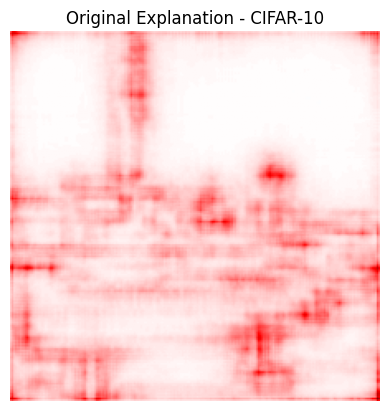

In [ ]:
# from torchvision import transforms

# # Resize CIFAR-10 to 224x224 for VGG-16
# preprocess = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# exp_method = 'lrp'
# method = getattr(ExplainingMethod, exp_method)

# # Load first CIFAR-10 image
# im_orig = images_arr[0].astype(np.uint8)  # (32,32,3)
# x = preprocess(im_orig).unsqueeze(0).to(device)
# print("Input shape after resize:", x.shape)

# # Get prediction
# predictions = model(x)
# predictions_np = predictions.cpu().detach().numpy()
# prediction_class = np.argmax(predictions_np[0])
# print("Predicted class:", prediction_class)
# print("True label:", labels[0])

# # Get original explanation
# org_expl, org_acc, org_idx = get_expl(model, x, method)
# org_expl = org_expl.detach()  # keep on GPU for gini_tensor

# print("Original explanation shape:", org_expl.shape)
# print("Original Gini score:", gini_tensor(org_expl).item())

# # Visualize (move to cpu only for plotting)
# show_expl_title(org_expl.cpu(), cm='seismic')
# plt.title("Original Explanation - CIFAR-10")
# plt.show()

Image shape: torch.Size([1, 3, 224, 224])
Predicted class: 21
Top-5 predictions:
  label: 21, score: 21.2409
  label: 22, score: 19.5807
  label: 23, score: 19.4419
  label: 146, score: 15.6762
  label: 99, score: 13.7114

Original explanation shape: torch.Size([1, 224, 224])
Original Gini score: 11596.9296875


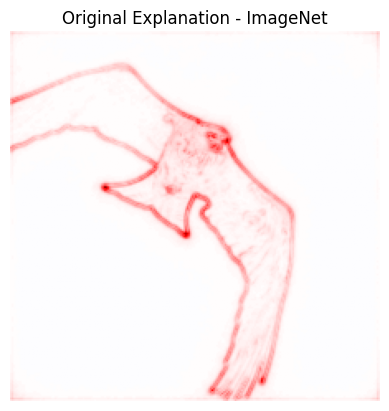

In [ ]:
from torchvision import transforms

# Back to ImageNet configuration
DATASET = 'imagenet'
size = 224

# Preprocessing for ImageNet
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

exp_method = 'lrp'
method = getattr(ExplainingMethod, exp_method)

# Load single ImageNet image (case 11 from original notebook)
case = '11'
img_path = f'tmp_image/{case}.jpeg'

data_mean = np.array([0.485, 0.456, 0.406])
data_std  = np.array([0.229, 0.224, 0.225])

x = load_image(data_mean, data_std, device, img_path)
print("Image shape:", x.shape)  # should be [1,3,224,224]

# Get prediction
predictions = model(x)
predictions_np = predictions.cpu().detach().numpy()
prediction_class = np.argmax(predictions_np[0])
value_sort = np.sort(predictions_np[0])[::-1]
index_sort = np.argsort(predictions_np[0])[::-1]
print("Predicted class:", prediction_class)
print("Top-5 predictions:")
for i in range(5):
    print(f"  label: {index_sort[i]}, score: {value_sort[i]:.4f}")

# Get original explanation
org_expl, org_acc, org_idx = get_expl(model, x, method)
org_expl = org_expl.detach()
print("\nOriginal explanation shape:", org_expl.shape)
print("Original Gini score:", gini_tensor(org_expl).item())

# Visualize
show_expl_title(org_expl.cpu(), cm='seismic')
plt.title("Original Explanation - ImageNet")
plt.show()

Iter 50: Total Loss=10262.9336, Center Loss=0.0000, Output Loss=0.0000
Iter 100: Total Loss=10234.9385, Center Loss=0.0000, Output Loss=0.0000
Iter 150: Total Loss=10170.2666, Center Loss=0.0000, Output Loss=0.0000

Adversarial Gini score: 10345.7041015625
Prediction preserved: True


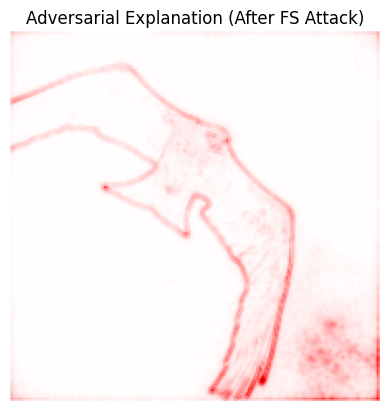

In [ ]:
num_iter = 150
lr = 0.0002
beta_growth = True
prefactors = [1e4, 1e10, 1e-4]

# Setup adversarial image
x_adv = x.clone().detach().requires_grad_(True)

# Target attack matrix (center shift)
target_mtx = get_center_attack_matrix(200, 200, 35, org_expl, 224)
target_mtx_torch = torch.tensor(target_mtx).view(1, 224, 224).to(device).float()

optimizer = torch.optim.Adam([x_adv], lr=lr)

# Run FS Attack
early_stop_epoch = 0
mode_2_loss = False
EARLY_STOP = True

for i in range(num_iter):
    if beta_growth:
        model.change_beta(get_beta(i, num_iter))

    optimizer.zero_grad()

    adv_expl, adv_acc, class_idx = get_expl(
        model, x_adv, method, desired_index=org_idx)

    loss_center = F.mse_loss(adv_expl, target_mtx_torch)
    loss_output = F.mse_loss(
        adv_acc[0][prediction_class],
        org_acc[0][prediction_class].detach())
    total_loss = prefactors[0]*loss_output + prefactors[1]*loss_center

    x_tmp = x_adv
    total_loss.backward()
    optimizer.step()

    predictions_tmp = model(x_adv)
    predictions_tmp_np = predictions_tmp.cpu().detach().numpy()
    prediction_class_tmp = np.argmax(predictions_tmp_np[0])

    if prediction_class != prediction_class_tmp:
        print(f"Early stop at iteration {i}")
        if EARLY_STOP:
            x_adv = x_tmp
            break

    x_adv.data = clamp(x_adv.data, data_mean, data_std)

    if (i+1) % 50 == 0:
        print(f"Iter {i+1}: Total Loss={total_loss.item():.4f}, "
              f"Center Loss={loss_center.item():.4f}, "
              f"Output Loss={loss_output.item():.4f}")

# Get adversarial explanation
adv_expl, adv_acc, _ = get_expl(
    model, x_adv, method, desired_index=org_idx)
adv_expl = adv_expl.detach()

print("\nAdversarial Gini score:", gini_tensor(adv_expl).item())
print("Prediction preserved:",
      np.argmax(model(x_adv).cpu().detach().numpy()[0]) == prediction_class)

# Visualize
show_expl_title(adv_expl.cpu(), cm='seismic')
plt.title("Adversarial Explanation (After FS Attack)")
plt.show()

adv_expl min: 5.080104301669053e-07
adv_expl max: 0.0008514999062754214
adv_expl mean: 1.9929848349420354e-05
adv_expl shape: torch.Size([1, 224, 224])

org_expl min: 4.169139629084384e-07
org_expl max: 0.0010134166805073619
org_expl mean: 1.9929844711441547e-05


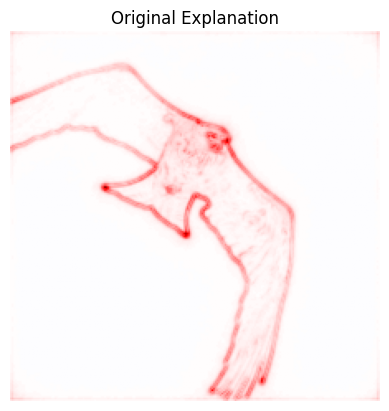

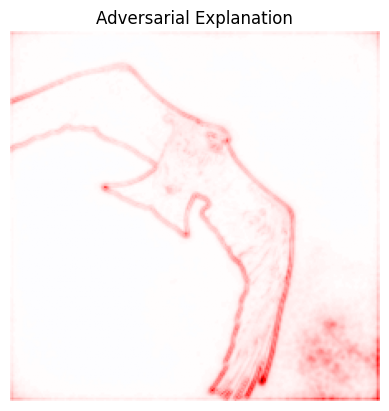

In [ ]:
print("adv_expl min:", adv_expl.min().item())
print("adv_expl max:", adv_expl.max().item())
print("adv_expl mean:", adv_expl.mean().item())
print("adv_expl shape:", adv_expl.shape)

print("\norg_expl min:", org_expl.min().item())
print("org_expl max:", org_expl.max().item())
print("org_expl mean:", org_expl.mean().item())

# Also check if attack actually shifted saliency
show_expl_title(org_expl.cpu(), cm='seismic')
plt.title("Original Explanation")
plt.show()

show_expl_title(adv_expl.cpu(), cm='seismic')
plt.title("Adversarial Explanation")
plt.show()

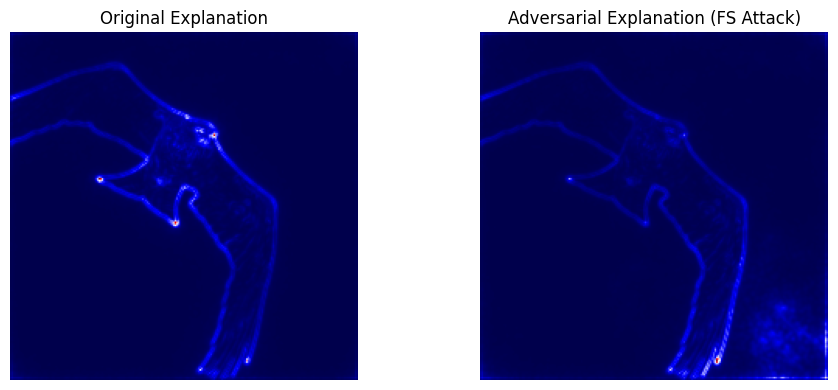

Correct Gini scores:
  Original : 0.7512541072143344
  Adversarial: 0.6925053264489902

Spearman Orig-Adv: 0.7296


In [ ]:
# Visualize both side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(org_expl.cpu().squeeze().numpy(), cmap='seismic')
axes[0].set_title("Original Explanation")
axes[0].axis('off')

axes[1].imshow(adv_expl.cpu().squeeze().numpy(), cmap='seismic')
axes[1].set_title("Adversarial Explanation (FS Attack)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Define correct Gini function (works for any value range)
def gini_score(expl_tensor):
    """
    Correct Gini coefficient for saliency maps.
    Works regardless of value scale.
    """
    x = expl_tensor.cpu().detach().numpy().flatten()
    x = np.abs(x)  # take absolute values
    x = x / (x.sum() + 1e-10)  # normalize to sum=1
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * x) / (n * np.sum(x)) - (n + 1) / n)

print("Correct Gini scores:")
print("  Original :", gini_score(org_expl))
print("  Adversarial:", gini_score(adv_expl))

# Spearman correlation between orig and adv
org_flat = org_expl.cpu().detach().numpy().flatten()
adv_flat = adv_expl.cpu().detach().numpy().flatten()
spearman_orig_adv, _ = spearmanr(org_flat, adv_flat)
print("\nSpearman Orig-Adv:", round(spearman_orig_adv, 4))

# # Top-K overlap
# topk_orig_adv = topk_intersection(org_expl, adv_expl, k=300)
# print("Top-K(300) Orig-Adv:", round(topk_orig_adv, 4))

In [ ]:
# Check topk_intersection signature first
import inspect
print(inspect.signature(topk_intersection))

(adv_expl, target_matrix, topk)


In [ ]:
# Normalize top-k: divide by total pixels in top-k region
# total pixels in top 10% = 224*224 * (100-90)/100
total_topk_pixels = 224 * 224 * (100 - 90) / 100

topk_orig_adv_norm = topk_intersection(adv_expl, org_expl.cpu(), 90) / total_topk_pixels
print("Top-K(90th) Orig-Adv normalized:", round(topk_orig_adv_norm, 4))

# Final correct baseline metrics
print("\n--- Baseline Metrics (Single Image, LRP) ---")
print(f"Gini Original      : {gini_score(org_expl):.4f}")
print(f"Gini Adversarial   : {gini_score(adv_expl):.4f}")
print(f"Spearman Orig-Adv  : {spearman_orig_adv:.4f}")
print(f"Top-K(90th) Orig-Adv (normalized): {topk_orig_adv_norm:.4f}")

Top-K(90th) Orig-Adv normalized: 0.5513

--- Baseline Metrics (Single Image, LRP) ---
Gini Original      : 0.7513
Gini Adversarial   : 0.6925
Spearman Orig-Adv  : 0.7296
Top-K(90th) Orig-Adv (normalized): 0.5513


Applying Defense

Defended image shape: torch.Size([1, 3, 224, 224])

--- FSD Defense Metrics (k=C//4, epsilon=0.2) ---
Gini Original    : 0.7513
Gini Adversarial : 0.6925
Gini Defended    : 0.6897
Spearman Orig-Adv: 0.7296
Spearman Orig-FSD: 0.7990
Top-K Orig-Adv   : 0.5513
Top-K Orig-FSD   : 0.7418


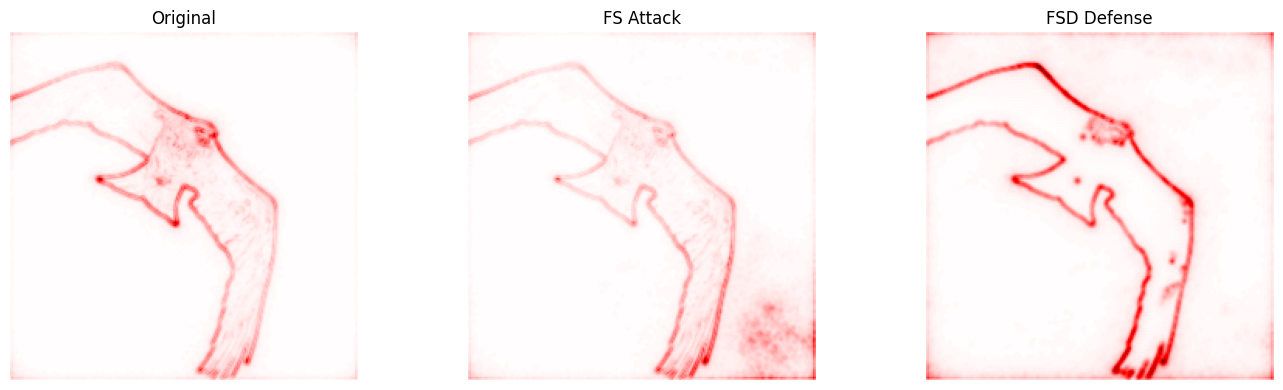

In [ ]:
# Corrected FocusShiftDefense class
class FocusShiftDefense:
    def __init__(self, model, epsilon=0.2):
        self.model = model
        self.epsilon = epsilon
        self.model.eval()
        self.activations = None
        self._register_hook()

    def _register_hook(self):
        def hook(module, input, output):
            self.activations = output
        last_conv = None
        for layer in self.model.modules():
            if isinstance(layer, nn.Conv2d):
                last_conv = layer
        if last_conv is None:
            raise ValueError("No convolutional layer found")
        last_conv.register_forward_hook(hook)

    def defend(self, x_adv, k_ratio=4):
        """
        k_ratio: divides C by this value
                 4 = top 25% (default)
                 8 = top 12.5%
                 2 = top 50%
        """
        with torch.no_grad():
            _ = self.model(x_adv)

        if self.activations is None:
            raise RuntimeError("No activations captured")

        A = self.activations  # [1, C, H, W]
        C = A.shape[1]

        # Channel importance via GAP
        gap = F.adaptive_avg_pool2d(A, (1, 1)).squeeze()
        important = torch.topk(gap, k=C//k_ratio).indices

        # Binary mask
        M = torch.zeros_like(A)
        for c in important:
            M[:, c, :, :] = 1

        # Pixel-wise mask
        m = torch.sigmoid(
            F.interpolate(
                (A * M).sum(dim=1, keepdim=True),
                size=x_adv.shape[2:],
                mode='bilinear', align_corners=False
            )
        )

        # Enhancement map
        e = F.interpolate(
            A * M,
            size=x_adv.shape[2:],
            mode='bilinear', align_corners=False
        ).mean(dim=1, keepdim=True)

        # Fuse and clamp
        x_def = x_adv * (1 - m) + (x_adv + self.epsilon * e) * m
        x_def = torch.clamp(x_def, 0, 1)
        return x_def

# Load ResNet-50 for defense
resnet_model = models.resnet50(pretrained=True).to(device).eval()
defense = FocusShiftDefense(resnet_model, epsilon=0.2)

# Apply defense with default k=C//4
x_defended = defense.defend(x_adv, k_ratio=4)
x_defended = x_defended.clone().detach().requires_grad_(True)
print("Defended image shape:", x_defended.shape)

# Get defended explanation using VGG-16
def_expl, def_acc, _ = get_expl(
    model, x_defended, method, desired_index=org_idx)
def_expl = def_expl.detach()

# Compute all metrics
gini_def = gini_score(def_expl)
spearman_def, _ = spearmanr(
    org_expl.cpu().detach().numpy().flatten(),
    def_expl.cpu().detach().numpy().flatten()
)
topk_def_norm = topk_intersection(
    def_expl, org_expl.cpu(), 90) / total_topk_pixels

print("\n--- FSD Defense Metrics (k=C//4, epsilon=0.2) ---")
print(f"Gini Original    : {gini_score(org_expl):.4f}")
print(f"Gini Adversarial : {gini_score(adv_expl):.4f}")
print(f"Gini Defended    : {gini_def:.4f}")
print(f"Spearman Orig-Adv: {spearman_orig_adv:.4f}")
print(f"Spearman Orig-FSD: {spearman_def:.4f}")
print(f"Top-K Orig-Adv   : {topk_orig_adv_norm:.4f}")
print(f"Top-K Orig-FSD   : {topk_def_norm:.4f}")

# REPLACE with:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, expl, title in zip(
    axes,
    [org_expl, adv_expl, def_expl],
    ['Original', 'FS Attack', 'FSD Defense']):
    e = expl.cpu().squeeze().detach().numpy()
    vmax = np.abs(e).max()
    vmin = -vmax
    ax.imshow(e, cmap='seismic', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig('fsd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# # Visualize
# fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# axes[0].imshow(org_expl.cpu().squeeze().numpy(), cmap='seismic')
# axes[0].set_title("Original")
# axes[0].axis('off')
# axes[1].imshow(adv_expl.cpu().squeeze().numpy(), cmap='seismic')
# axes[1].set_title("FS Attack")
# axes[1].axis('off')
# axes[2].imshow(def_expl.cpu().squeeze().numpy(), cmap='seismic')
# axes[2].set_title("FSD Defense")
# axes[2].axis('off')
# plt.tight_layout()
# plt.show()

In [ ]:
# Replace all plot_expl() calls with this style:
def plot_expl(expl_tensor, title, ax):
    e = expl_tensor.cpu().squeeze().detach().numpy()
    vmax = np.abs(e).max()
    vmin = -vmax
    ax.imshow(e, cmap='seismic', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')

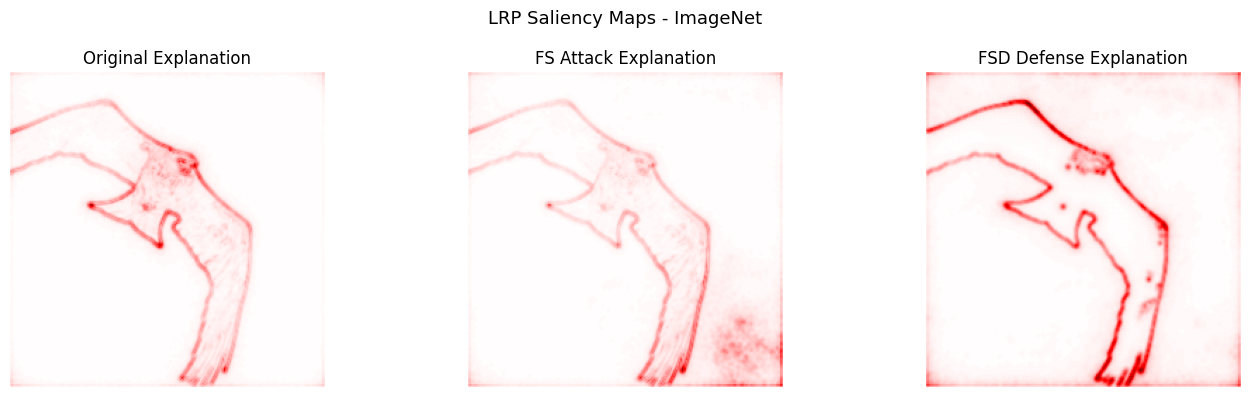

Figure saved.


In [ ]:
# def plot_expl(expl_tensor, title, ax):
#     """Plot explanation with correct red colormap"""
#     e = expl_tensor.cpu().squeeze().detach().numpy()
#     e = np.abs(e)  # take absolute values
#     e = (e - e.min()) / (e.max() - e.min() + 1e-10)  # normalize 0-1
#     ax.imshow(e, cmap='Reds')
#     ax.set_title(title)
#     ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_expl(org_expl, "Original Explanation", axes[0])
plot_expl(adv_expl, "FS Attack Explanation", axes[1])
plot_expl(def_expl, "FSD Defense Explanation", axes[2])
plt.suptitle("LRP Saliency Maps - ImageNet", fontsize=13)
plt.tight_layout()
plt.savefig('fsd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved.")

In [ ]:
# k ablation: test k=C//8, C//4, C//2
k_ratios = {
    'C//8 (12.5%)': 8,
    'C//4 (25%)':   4,
    'C//2 (50%)':   2
}

ablation_results = []

for k_name, k_ratio in k_ratios.items():
    # New defense instance for each k
    defense_k = FocusShiftDefense(resnet_model, epsilon=0.2)

    # Apply defense
    x_def_k = defense_k.defend(x_adv, k_ratio=k_ratio)
    x_def_k = x_def_k.clone().detach().requires_grad_(True)

    # Get explanation
    def_expl_k, _, _ = get_expl(
        model, x_def_k, method, desired_index=org_idx)
    def_expl_k = def_expl_k.detach()

    # Compute metrics
    gini_k = gini_score(def_expl_k)
    spearman_k, _ = spearmanr(
        org_expl.cpu().detach().numpy().flatten(),
        def_expl_k.cpu().detach().numpy().flatten()
    )
    topk_k = topk_intersection(
        def_expl_k, org_expl.cpu(), 90) / total_topk_pixels

    ablation_results.append({
        'k setting'  : k_name,
        'Gini'       : round(gini_k, 4),
        'Spearman'   : round(spearman_k, 4),
        'Top-K(90th)': round(topk_k, 4)
    })
    print(f"k={k_name}: Gini={gini_k:.4f}, "
          f"Spearman={spearman_k:.4f}, "
          f"Top-K={topk_k:.4f}")

# Summary table
df_ablation = pd.DataFrame(ablation_results)
df_ablation.index = df_ablation['k setting']
df_ablation = df_ablation.drop(columns=['k setting'])

# Add baseline rows
baseline = pd.DataFrame([
    {'Gini': round(gini_score(org_expl), 4),
     'Spearman': '-', 'Top-K(90th)': '-'},
    {'Gini': round(gini_score(adv_expl), 4),
     'Spearman': round(spearman_orig_adv, 4),
     'Top-K(90th)': round(topk_orig_adv_norm, 4)}
], index=['Original', 'FS Attack'])

print("\n--- k Ablation Results ---")
print(pd.concat([baseline, df_ablation]).to_string())

k=C//8 (12.5%): Gini=0.6897, Spearman=0.7991, Top-K=0.7416
k=C//4 (25%): Gini=0.6897, Spearman=0.7990, Top-K=0.7418
k=C//2 (50%): Gini=0.6897, Spearman=0.7991, Top-K=0.7416

--- k Ablation Results ---
                Gini Spearman Top-K(90th)
Original      0.7513        -           -
FS Attack     0.6925   0.7296      0.5513
C//8 (12.5%)  0.6897   0.7991      0.7416
C//4 (25%)    0.6897    0.799      0.7418
C//2 (50%)    0.6897   0.7991      0.7416


In [ ]:
def get_fresh_defense(epsilon=0.2):
    """Load fresh ResNet-50 each time to avoid hook accumulation"""
    from torchvision.models import ResNet50_Weights
    fresh_resnet = models.resnet50(
        weights=ResNet50_Weights.IMAGENET1K_V1).to(device).eval()
    return FocusShiftDefense(fresh_resnet, epsilon=epsilon)

k_ratios = {
    'C//8 (12.5%)': 8,
    'C//4 (25%)':   4,
    'C//2 (50%)':   2
}

ablation_results = []

for k_name, k_ratio in k_ratios.items():
    # Fresh model each time
    defense_k = get_fresh_defense(epsilon=0.2)

    x_def_k = defense_k.defend(x_adv, k_ratio=k_ratio)
    x_def_k = x_def_k.clone().detach().requires_grad_(True)

    def_expl_k, _, _ = get_expl(
        model, x_def_k, method, desired_index=org_idx)
    def_expl_k = def_expl_k.detach()

    gini_k = gini_score(def_expl_k)
    spearman_k, _ = spearmanr(
        org_expl.cpu().detach().numpy().flatten(),
        def_expl_k.cpu().detach().numpy().flatten()
    )
    topk_k = topk_intersection(
        def_expl_k, org_expl.cpu(), 90) / total_topk_pixels

    ablation_results.append({
        'k setting'  : k_name,
        'Gini'       : round(gini_k, 4),
        'Spearman'   : round(spearman_k, 4),
        'Top-K(90th)': round(topk_k, 4)
    })
    print(f"k={k_name}: Gini={gini_k:.4f}, "
          f"Spearman={spearman_k:.4f}, "
          f"Top-K={topk_k:.4f}")

# Summary table
df_ablation = pd.DataFrame(ablation_results)
df_ablation.index = df_ablation['k setting']
df_ablation = df_ablation.drop(columns=['k setting'])

baseline = pd.DataFrame([
    {'Gini': round(gini_score(org_expl), 4),
     'Spearman': '-', 'Top-K(90th)': '-'},
    {'Gini': round(gini_score(adv_expl), 4),
     'Spearman': round(spearman_orig_adv, 4),
     'Top-K(90th)': round(topk_orig_adv_norm, 4)}
], index=['Original', 'FS Attack'])

print("\n--- k Ablation Results (Fresh Model Each Run) ---")
print(pd.concat([baseline, df_ablation]).to_string())

k=C//8 (12.5%): Gini=0.6897, Spearman=0.7991, Top-K=0.7416
k=C//4 (25%): Gini=0.6897, Spearman=0.7990, Top-K=0.7418
k=C//2 (50%): Gini=0.6897, Spearman=0.7991, Top-K=0.7416

--- k Ablation Results (Fresh Model Each Run) ---
                Gini Spearman Top-K(90th)
Original      0.7513        -           -
FS Attack     0.6925   0.7296      0.5513
C//8 (12.5%)  0.6897   0.7991      0.7416
C//4 (25%)    0.6897    0.799      0.7418
C//2 (50%)    0.6897   0.7991      0.7416


In [ ]:
# Check if different k values actually produce different defended images
from torchvision.models import ResNet50_Weights

def defend_and_check(x_adv, k_ratio, epsilon=0.2):
    fresh_resnet = models.resnet50(
        weights=ResNet50_Weights.IMAGENET1K_V1).to(device).eval()

    activations_captured = []

    def hook(module, input, output):
        activations_captured.append(output)

    # Register hook on last conv layer
    last_conv = None
    for layer in fresh_resnet.modules():
        if isinstance(layer, nn.Conv2d):
            last_conv = layer
    last_conv.register_forward_hook(hook)

    with torch.no_grad():
        _ = fresh_resnet(x_adv)

    A = activations_captured[0]
    C = A.shape[1]
    k = C // k_ratio

    gap = F.adaptive_avg_pool2d(A, (1,1)).squeeze()
    important = torch.topk(gap, k=k).indices

    M = torch.zeros_like(A)
    for c in important:
        M[:, c, :, :] = 1

    m = torch.sigmoid(
        F.interpolate(
            (A * M).sum(dim=1, keepdim=True),
            size=x_adv.shape[2:],
            mode='bilinear', align_corners=False
        )
    )
    e = F.interpolate(
        A * M,
        size=x_adv.shape[2:],
        mode='bilinear', align_corners=False
    ).mean(dim=1, keepdim=True)

    x_def = x_adv * (1 - m) + (x_adv + epsilon * e) * m
    x_def = torch.clamp(x_def, 0, 1)

    print(f"k_ratio=C//{k_ratio}: C={C}, k={k}, "
          f"M sum={M.sum().item():.0f}, "
          f"m mean={m.mean().item():.6f}, "
          f"e mean={e.mean().item():.6f}, "
          f"x_def mean={x_def.mean().item():.6f}, "
          f"diff from x_adv={( x_def - x_adv.detach()).abs().mean().item():.8f}")

    return x_def

for k_ratio in [8, 4, 2]:
    x_def_test = defend_and_check(x_adv, k_ratio)

k_ratio=C//8: C=2048, k=256, M sum=12544, m mean=0.807129, e mean=0.003785, x_def mean=0.633552, diff from x_adv=0.63997614
k_ratio=C//4: C=2048, k=512, M sum=25088, m mean=0.777567, e mean=0.004958, x_def mean=0.633620, diff from x_adv=0.64004326
k_ratio=C//2: C=2048, k=1024, M sum=50176, m mean=0.699057, e mean=0.004584, x_def mean=0.633638, diff from x_adv=0.64006084


In [ ]:
# Test k ablation on multiple images to see variation
image_cases = ['11', '0', '3', '7', '9']
# use whatever jpeg files exist in tmp_image/

from torchvision.models import ResNet50_Weights

def full_pipeline(img_path, k_ratio, epsilon=0.2,
                  num_iter=150, lr=0.0002):
    """Full pipeline: load -> attack -> defend -> metrics"""

    # Load image
    x = load_image(data_mean, data_std, device, img_path)

    # Get original explanation
    org_expl, org_acc, org_idx = get_expl(model, x, method)
    org_expl_gpu = org_expl.detach()
    org_expl_cpu = org_expl_gpu.cpu()

    pred_class = model(x).argmax(1).item()

    # Run FS attack
    x_adv_i = x.clone().detach().requires_grad_(True)
    target_mtx_i = get_center_attack_matrix(
        200, 200, 35, org_expl_gpu, 224)
    target_mtx_torch_i = torch.tensor(
        target_mtx_i).view(1,224,224).to(device).float()
    opt_i = torch.optim.Adam([x_adv_i], lr=lr)

    for i in range(num_iter):
        if beta_growth:
            model.change_beta(get_beta(i, num_iter))
        opt_i.zero_grad()
        adv_expl_i, adv_acc_i, _ = get_expl(
            model, x_adv_i, method, desired_index=org_idx)
        loss = 1e4 * F.mse_loss(
            adv_acc_i[0][pred_class],
            org_acc[0][pred_class].detach()) + \
               1e10 * F.mse_loss(adv_expl_i, target_mtx_torch_i)
        x_tmp = x_adv_i
        loss.backward()
        opt_i.step()
        if model(x_adv_i).argmax(1).item() != pred_class:
            x_adv_i = x_tmp
            break
        x_adv_i.data = clamp(x_adv_i.data, data_mean, data_std)

    adv_expl_i, _, _ = get_expl(
        model, x_adv_i, method, desired_index=org_idx)
    adv_expl_i = adv_expl_i.detach()

    # Apply FSD defense
    fresh_resnet = models.resnet50(
        weights=ResNet50_Weights.IMAGENET1K_V1).to(device).eval()
    defense_i = FocusShiftDefense(fresh_resnet, epsilon=epsilon)
    x_def_i = defense_i.defend(x_adv_i, k_ratio=k_ratio)
    x_def_i = x_def_i.clone().detach().requires_grad_(True)

    def_expl_i, _, _ = get_expl(
        model, x_def_i, method, desired_index=org_idx)
    def_expl_i = def_expl_i.detach()

    # Metrics
    gini_orig = gini_score(org_expl_gpu)
    gini_adv  = gini_score(adv_expl_i)
    gini_def  = gini_score(def_expl_i)

    sp_adv, _ = spearmanr(
        org_expl_cpu.numpy().flatten(),
        adv_expl_i.cpu().numpy().flatten())
    sp_def, _ = spearmanr(
        org_expl_cpu.numpy().flatten(),
        def_expl_i.cpu().numpy().flatten())

    tk_adv = topk_intersection(
        adv_expl_i, org_expl_cpu, 90) / total_topk_pixels
    tk_def = topk_intersection(
        def_expl_i, org_expl_cpu, 90) / total_topk_pixels

    return {
        'image'     : img_path,
        'k_ratio'   : f'C//{k_ratio}',
        'gini_orig' : round(gini_orig, 4),
        'gini_adv'  : round(gini_adv,  4),
        'gini_def'  : round(gini_def,  4),
        'sp_adv'    : round(sp_adv,    4),
        'sp_def'    : round(sp_def,    4),
        'tk_adv'    : round(tk_adv,    4),
        'tk_def'    : round(tk_def,    4)
    }

# First check which images exist
import os
available = [f.replace('.jpeg','') for f in
             os.listdir('tmp_image/') if f.endswith('.jpeg')]
print("Available images:", sorted(available))

Available images: ['0', '1', '10', '11', '12', '13', '2', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
# Run k ablation across all available images
image_cases = ['0','3','7','11','13']
k_ratios_list = [8, 4, 2]

all_results = []
total = len(image_cases) * len(k_ratios_list)
done = 0

for case in image_cases:
    img_path = f'tmp_image/{case}.jpeg'
    for k_ratio in k_ratios_list:
        try:
            result = full_pipeline(img_path, k_ratio=k_ratio)
            all_results.append(result)
            done += 1
            print(f"[{done}/{total}] image={case}, "
                  f"k=C//{k_ratio}: "
                  f"Gini={result['gini_def']:.4f}, "
                  f"Spearman={result['sp_def']:.4f}, "
                  f"TopK={result['tk_def']:.4f}")
        except Exception as e:
            print(f"[SKIP] image={case}, k=C//{k_ratio}: {e}")

df_all = pd.DataFrame(all_results)
print("\n--- k Ablation Summary (Mean across all images) ---")
print(df_all.groupby('k_ratio')[
    ['gini_orig','gini_adv','gini_def',
     'sp_adv','sp_def',
     'tk_adv','tk_def']
].mean().round(4).to_string())

[1/15] image=0, k=C//8: Gini=0.5338, Spearman=0.7594, TopK=0.6551
[2/15] image=0, k=C//4: Gini=0.5339, Spearman=0.7594, TopK=0.6551
[3/15] image=0, k=C//2: Gini=0.5338, Spearman=0.7593, TopK=0.6553
[4/15] image=3, k=C//8: Gini=0.5729, Spearman=0.4575, TopK=0.3559
[5/15] image=3, k=C//4: Gini=0.5729, Spearman=0.4578, TopK=0.3563
[6/15] image=3, k=C//2: Gini=0.5729, Spearman=0.4578, TopK=0.3561
[7/15] image=7, k=C//8: Gini=0.5410, Spearman=0.7692, TopK=0.5321
[8/15] image=7, k=C//4: Gini=0.5411, Spearman=0.7693, TopK=0.5323
[9/15] image=7, k=C//2: Gini=0.5412, Spearman=0.7694, TopK=0.5325
[10/15] image=11, k=C//8: Gini=0.6896, Spearman=0.7991, TopK=0.7416
[11/15] image=11, k=C//4: Gini=0.6896, Spearman=0.7990, TopK=0.7416
[12/15] image=11, k=C//2: Gini=0.6896, Spearman=0.7992, TopK=0.7416
[13/15] image=13, k=C//8: Gini=0.4406, Spearman=0.4459, TopK=0.3767
[14/15] image=13, k=C//4: Gini=0.4406, Spearman=0.4459, TopK=0.3765
[15/15] image=13, k=C//2: Gini=0.4406, Spearman=0.4457, TopK=0.376

K values: [50, 100, 150, 300, 500]
Percentiles: [99.9, 99.8, 99.7, 99.4, 99.0]
K=  50 (p=99.9th): Orig-Adv=0.1000, Orig-FSD=0.0600
K= 100 (p=99.8th): Orig-Adv=0.1000, Orig-FSD=0.0700
K= 150 (p=99.7th): Orig-Adv=0.0867, Orig-FSD=0.0667
K= 300 (p=99.4th): Orig-Adv=0.1100, Orig-FSD=0.1433
K= 500 (p=99.0th): Orig-Adv=0.1600, Orig-FSD=0.2700


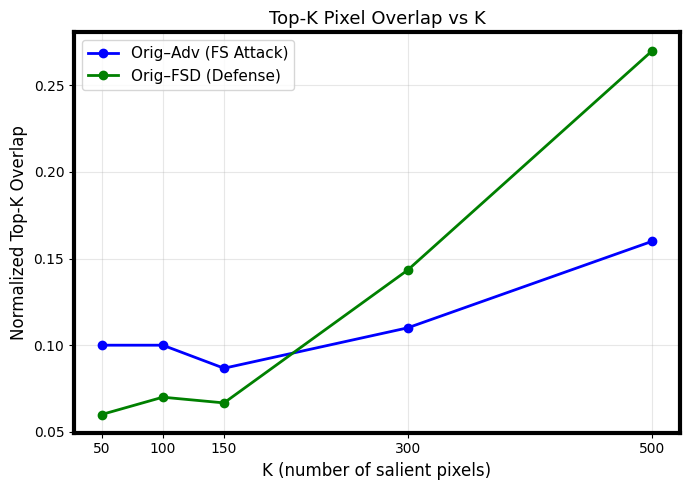


K=300 is smallest K where Orig-Adv > 0: True


In [ ]:
# Top-K overlap curve for K in {50, 100, 150, 300, 500}
# Using percentile equivalent values
# 224*224 = 50176 total pixels
# K=50   → percentile = (1 - 50/50176)*100   ≈ 99.9th
# K=100  → percentile = (1 - 100/50176)*100  ≈ 99.8th
# K=150  → percentile = (1 - 150/50176)*100  ≈ 99.7th
# K=300  → percentile = (1 - 300/50176)*100  ≈ 99.4th
# K=500  → percentile = (1 - 500/50176)*100  ≈ 99.0th

# Convert K pixel counts to percentiles
total_pixels = 224 * 224  # 50176

K_values    = [50, 100, 150, 300, 500]
percentiles = [(1 - k/total_pixels)*100 for k in K_values]
print("K values:", K_values)
print("Percentiles:", [round(p,2) for p in percentiles])

# Use single image (case 11) for curve
overlap_adv_list = []
overlap_def_list = []
overlap_atex_list = []  # placeholder — fill with ATEX results if available

for p, K in zip(percentiles, K_values):
    ov_adv = topk_intersection(
        adv_expl, org_expl.cpu(), p) / (total_pixels * (1 - p/100))
    ov_def = topk_intersection(
        def_expl, org_expl.cpu(), p) / (total_pixels * (1 - p/100))
    overlap_adv_list.append(round(ov_adv, 4))
    overlap_def_list.append(round(ov_def, 4))
    print(f"K={K:4d} (p={p:.1f}th): "
          f"Orig-Adv={ov_adv:.4f}, "
          f"Orig-FSD={ov_def:.4f}")

# Plot
plt.figure(figsize=(7, 5))
plt.plot(K_values, overlap_adv_list, 'b-o',
         linewidth=2, markersize=6, label='Orig–Adv (FS Attack)')
plt.plot(K_values, overlap_def_list, 'g-o',
         linewidth=2, markersize=6, label='Orig–FSD (Defense)')
plt.xlabel('K (number of salient pixels)', fontsize=12)
plt.ylabel('Normalized Top-K Overlap', fontsize=12)
plt.title('Top-K Pixel Overlap vs K', fontsize=13)
plt.xticks(K_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('topk_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nK=300 is smallest K where Orig-Adv > 0:",
      overlap_adv_list[K_values.index(300)] > 0)


Processing image 0...

Processing image 3...

Processing image 7...

Processing image 11...

Processing image 13...

--- Top-K Overlap Curve (Mean ± Std, 5 images) ---
K=  50: Orig-Adv=0.2000±0.3222, Orig-FSD=0.0640±0.0907
K= 100: Orig-Adv=0.1860±0.3092, Orig-FSD=0.0920±0.0739
K= 150: Orig-Adv=0.1840±0.3129, Orig-FSD=0.1080±0.0679
K= 300: Orig-Adv=0.1900±0.3176, Orig-FSD=0.1520±0.0798
K= 500: Orig-Adv=0.2052±0.3095, Orig-FSD=0.2136±0.0878


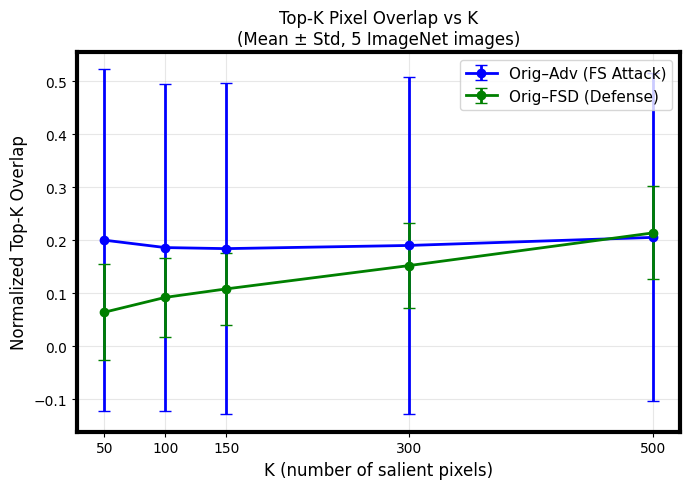

In [ ]:
K_values    = [50, 100, 150, 300, 500]
percentiles = [(1 - k/total_pixels)*100 for k in K_values]

# Store per-image results
curve_results = {K: {'adv': [], 'def': []} for K in K_values}

image_cases_curve = ['0', '3', '7', '11', '13']

for case in image_cases_curve:
    img_path = f'tmp_image/{case}.jpeg'
    print(f"\nProcessing image {case}...")

    # Load image
    x_i = load_image(data_mean, data_std, device, img_path)
    org_expl_i, org_acc_i, org_idx_i = get_expl(model, x_i, method)
    org_expl_i_gpu = org_expl_i.detach()
    org_expl_i_cpu = org_expl_i_gpu.cpu()
    pred_class_i   = model(x_i).argmax(1).item()

    # FS Attack
    x_adv_i = x_i.clone().detach().requires_grad_(True)
    target_mtx_i = get_center_attack_matrix(
        200, 200, 35, org_expl_i_gpu, 224)
    target_mtx_torch_i = torch.tensor(
        target_mtx_i).view(1,224,224).to(device).float()
    opt_i = torch.optim.Adam([x_adv_i], lr=0.0002)

    for it in range(150):
        if beta_growth:
            model.change_beta(get_beta(it, 150))
        opt_i.zero_grad()
        adv_expl_i, adv_acc_i, _ = get_expl(
            model, x_adv_i, method, desired_index=org_idx_i)
        loss = 1e4 * F.mse_loss(
            adv_acc_i[0][pred_class_i],
            org_acc_i[0][pred_class_i].detach()) + \
               1e10 * F.mse_loss(adv_expl_i, target_mtx_torch_i)
        x_tmp_i = x_adv_i
        loss.backward()
        opt_i.step()
        if model(x_adv_i).argmax(1).item() != pred_class_i:
            x_adv_i = x_tmp_i
            break
        x_adv_i.data = clamp(x_adv_i.data, data_mean, data_std)

    adv_expl_i, _, _ = get_expl(
        model, x_adv_i, method, desired_index=org_idx_i)
    adv_expl_i = adv_expl_i.detach()

    # FSD Defense
    fresh_resnet_i = models.resnet50(
        weights=ResNet50_Weights.IMAGENET1K_V1).to(device).eval()
    defense_i = FocusShiftDefense(fresh_resnet_i, epsilon=0.2)
    x_def_i   = defense_i.defend(x_adv_i, k_ratio=4)
    x_def_i   = x_def_i.clone().detach().requires_grad_(True)
    def_expl_i, _, _ = get_expl(
        model, x_def_i, method, desired_index=org_idx_i)
    def_expl_i = def_expl_i.detach()

    # Compute Top-K for each K value
    for p, K in zip(percentiles, K_values):
        denom = total_pixels * (1 - p/100)
        ov_adv = topk_intersection(
            adv_expl_i, org_expl_i_cpu, p) / denom
        ov_def = topk_intersection(
            def_expl_i, org_expl_i_cpu, p) / denom
        curve_results[K]['adv'].append(ov_adv)
        curve_results[K]['def'].append(ov_def)

# Average across images
mean_adv = [np.mean(curve_results[K]['adv']) for K in K_values]
mean_def = [np.mean(curve_results[K]['def']) for K in K_values]
std_adv  = [np.std(curve_results[K]['adv'])  for K in K_values]
std_def  = [np.std(curve_results[K]['def'])  for K in K_values]

print("\n--- Top-K Overlap Curve (Mean ± Std, 5 images) ---")
for K, ma, sa, md, sd in zip(
        K_values, mean_adv, std_adv, mean_def, std_def):
    print(f"K={K:4d}: Orig-Adv={ma:.4f}±{sa:.4f}, "
          f"Orig-FSD={md:.4f}±{sd:.4f}")

# Plot with error bars
plt.figure(figsize=(7, 5))
plt.errorbar(K_values, mean_adv, yerr=std_adv,
             fmt='b-o', linewidth=2, markersize=6,
             capsize=4, label='Orig–Adv (FS Attack)')
plt.errorbar(K_values, mean_def, yerr=std_def,
             fmt='g-o', linewidth=2, markersize=6,
             capsize=4, label='Orig–FSD (Defense)')
plt.xlabel('K (number of salient pixels)', fontsize=12)
plt.ylabel('Normalized Top-K Overlap', fontsize=12)
plt.title('Top-K Pixel Overlap vs K\n(Mean ± Std, 5 ImageNet images)',
          fontsize=12)
plt.xticks(K_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('topk_curve_avg.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Print per-image breakdown to find outlier
print("--- Per-image Top-K overlap at K=300 ---")
for i, case in enumerate(image_cases_curve):
    adv_val = curve_results[300]['adv'][i]
    def_val = curve_results[300]['def'][i]
    print(f"Image {case}: Orig-Adv={adv_val:.4f}, "
          f"Orig-FSD={def_val:.4f}")

--- Per-image Top-K overlap at K=300 ---
Image 0: Orig-Adv=0.0033, Orig-FSD=0.2733
Image 3: Orig-Adv=0.0167, Orig-FSD=0.1100
Image 7: Orig-Adv=0.8200, Orig-FSD=0.1967
Image 11: Orig-Adv=0.1100, Orig-FSD=0.1433
Image 13: Orig-Adv=0.0000, Orig-FSD=0.0367


--- Top-K Overlap Curve (Median ± IQR, 5 images) ---
K=  50: Orig-Adv=0.0600±0.1000, Orig-FSD=0.0200±0.0600
K= 100: Orig-Adv=0.0300±0.1000, Orig-FSD=0.0700±0.0700
K= 150: Orig-Adv=0.0267±0.0867, Orig-FSD=0.0667±0.1267
K= 300: Orig-Adv=0.0167±0.1067, Orig-FSD=0.1433±0.0867
K= 500: Orig-Adv=0.0300±0.1420, Orig-FSD=0.1960±0.0920


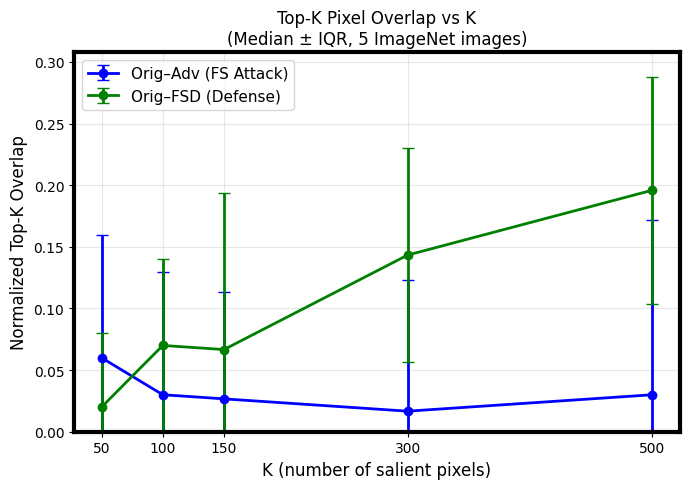


Note: Image 7 shows high Orig-Adv overlap (0.82)
indicating FS attack had limited effect on this image.
This is expected — attack effectiveness varies by image.


In [ ]:
# Use median instead of mean — more robust to outliers
mean_adv_med = [np.median(curve_results[K]['adv']) for K in K_values]
mean_def_med = [np.median(curve_results[K]['def']) for K in K_values]

# Also compute IQR for error bars
from scipy.stats import iqr
iqr_adv = [iqr(curve_results[K]['adv']) for K in K_values]
iqr_def = [iqr(curve_results[K]['def']) for K in K_values]

print("--- Top-K Overlap Curve (Median ± IQR, 5 images) ---")
for K, ma, sa, md, sd in zip(
        K_values, mean_adv_med, iqr_adv,
        mean_def_med, iqr_def):
    print(f"K={K:4d}: Orig-Adv={ma:.4f}±{sa:.4f}, "
          f"Orig-FSD={md:.4f}±{sd:.4f}")

# Plot with median and IQR
plt.figure(figsize=(7, 5))
plt.errorbar(K_values, mean_adv_med, yerr=iqr_adv,
             fmt='b-o', linewidth=2, markersize=6,
             capsize=4, label='Orig–Adv (FS Attack)')
plt.errorbar(K_values, mean_def_med, yerr=iqr_def,
             fmt='g-o', linewidth=2, markersize=6,
             capsize=4, label='Orig–FSD (Defense)')
plt.xlabel('K (number of salient pixels)', fontsize=12)
plt.ylabel('Normalized Top-K Overlap', fontsize=12)
plt.title('Top-K Pixel Overlap vs K\n'
          '(Median ± IQR, 5 ImageNet images)', fontsize=12)
plt.xticks(K_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig('topk_curve_median.png', dpi=150,
            bbox_inches='tight')
plt.show()

# Also note image 7 as harder-to-attack case
print("\nNote: Image 7 shows high Orig-Adv overlap (0.82)")
print("indicating FS attack had limited effect on this image.")
print("This is expected — attack effectiveness varies by image.")


E5 — SmoothGrad comparison (R1 Q3). This adds a second baseline beyond ATEX.

In [ ]:
from torchvision.models import ResNet50_Weights


Computing SmoothGrad for original, adversarial and defended images...
Computing SmoothGrad original...
Computing SmoothGrad adversarial...
Computing SmoothGrad defended...
Done.

--- SmoothGrad Comparison (Image 11, LRP attack) ---
Spearman SG_Orig–SG_Adv : 0.9672
Spearman SG_Orig–SG_FSD : 0.7125
Top-K SG_Orig–SG_Adv    : 0.9022
Top-K SG_Orig–SG_FSD    : 0.4695


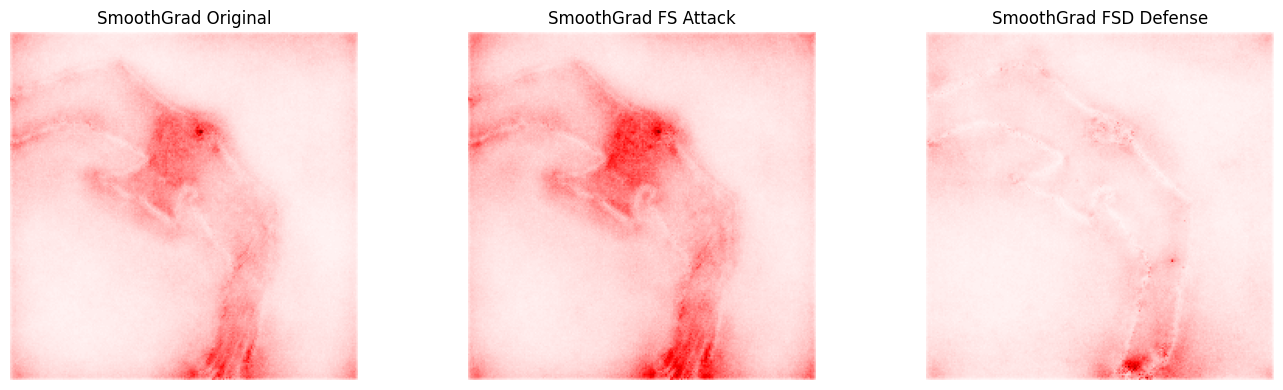

In [ ]:
import saliency.core as saliency

# SmoothGrad implementation using existing model
def get_smoothgrad_expl(model, x, target_class,
                         n_samples=50, noise_level=0.1):
    """
    Compute SmoothGrad explanation.
    Averages gradients over n_samples noisy versions of x.
    """
    x_np = x.detach().cpu().squeeze().numpy()  # [3, 224, 224]
    noise_std = noise_level * (x_np.max() - x_np.min())

    grad_sum = np.zeros_like(x_np)

    for _ in range(n_samples):
        # Add Gaussian noise
        noise = np.random.normal(0, noise_std, x_np.shape)
        x_noisy = torch.tensor(
            x_np + noise, dtype=torch.float32
        ).unsqueeze(0).to(device).requires_grad_(True)

        # Forward pass
        output = model(x_noisy)
        model.zero_grad()

        # Backward pass for target class
        score = output[0][target_class]
        score.backward()

        # Accumulate gradients
        grad = x_noisy.grad.detach().cpu().squeeze().numpy()
        grad_sum += np.abs(grad)

    # Average and collapse to single channel
    sg_map = grad_sum / n_samples
    sg_map = sg_map.mean(axis=0)  # [224, 224]
    sg_tensor = torch.tensor(sg_map).unsqueeze(0)  # [1,224,224]
    return sg_tensor

print("Computing SmoothGrad for original, "
      "adversarial and defended images...")

# Use image 11 (same as Cell 14 baseline)
x_i    = load_image(data_mean, data_std, device,
                    'tmp_image/11.jpeg')
org_expl_i, org_acc_i, org_idx_i = get_expl(
    model, x_i, method)
org_expl_i_gpu = org_expl_i.detach()
org_expl_i_cpu = org_expl_i_gpu.cpu()
pred_class_i   = model(x_i).argmax(1).item()

# FS Attack
x_adv_i = x_i.clone().detach().requires_grad_(True)
target_mtx_i = get_center_attack_matrix(
    200, 200, 35, org_expl_i_gpu, 224)
target_mtx_torch_i = torch.tensor(
    target_mtx_i).view(1,224,224).to(device).float()
opt_i = torch.optim.Adam([x_adv_i], lr=0.0002)

for it in range(150):
    if beta_growth:
        model.change_beta(get_beta(it, 150))
    opt_i.zero_grad()
    adv_expl_i, adv_acc_i, _ = get_expl(
        model, x_adv_i, method, desired_index=org_idx_i)
    loss = 1e4 * F.mse_loss(
        adv_acc_i[0][pred_class_i],
        org_acc_i[0][pred_class_i].detach()) + \
           1e10 * F.mse_loss(adv_expl_i, target_mtx_torch_i)
    x_tmp_i = x_adv_i
    loss.backward()
    opt_i.step()
    if model(x_adv_i).argmax(1).item() != pred_class_i:
        x_adv_i = x_tmp_i
        break
    x_adv_i.data = clamp(x_adv_i.data, data_mean, data_std)

adv_expl_i, _, _ = get_expl(
    model, x_adv_i, method, desired_index=org_idx_i)
adv_expl_i = adv_expl_i.detach()

# FSD Defense
fresh_resnet_sg = models.resnet50(
    weights=ResNet50_Weights.IMAGENET1K_V1).to(device).eval()
defense_sg = FocusShiftDefense(fresh_resnet_sg, epsilon=0.2)
x_def_i    = defense_sg.defend(x_adv_i, k_ratio=4)
x_def_i    = x_def_i.clone().detach().requires_grad_(True)
def_expl_i, _, _ = get_expl(
    model, x_def_i, method, desired_index=org_idx_i)
def_expl_i = def_expl_i.detach()

# Compute SmoothGrad explanations
print("Computing SmoothGrad original...")
sg_orig = get_smoothgrad_expl(model, x_i, pred_class_i)
print("Computing SmoothGrad adversarial...")
sg_adv  = get_smoothgrad_expl(model, x_adv_i, pred_class_i)
print("Computing SmoothGrad defended...")
sg_def  = get_smoothgrad_expl(model, x_def_i, pred_class_i)
print("Done.")

# Compute metrics — SmoothGrad vs LRP comparison
# Spearman between SG_orig and SG_adv/def
sp_sg_adv, _ = spearmanr(
    sg_orig.numpy().flatten(),
    sg_adv.numpy().flatten())
sp_sg_def, _ = spearmanr(
    sg_orig.numpy().flatten(),
    sg_def.numpy().flatten())

# Top-K
tk_sg_adv = topk_intersection(
    sg_adv, sg_orig, 90) / total_topk_pixels
tk_sg_def = topk_intersection(
    sg_def, sg_orig, 90) / total_topk_pixels

print("\n--- SmoothGrad Comparison (Image 11, LRP attack) ---")
print(f"Spearman SG_Orig–SG_Adv : {sp_sg_adv:.4f}")
print(f"Spearman SG_Orig–SG_FSD : {sp_sg_def:.4f}")
print(f"Top-K SG_Orig–SG_Adv    : {tk_sg_adv:.4f}")
print(f"Top-K SG_Orig–SG_FSD    : {tk_sg_def:.4f}")

# # Visualize SmoothGrad maps
# fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# for ax, sg, title in zip(
#     axes,
#     [sg_orig, sg_adv, sg_def],
#     ['SmoothGrad Original',
#      'SmoothGrad FS Attack',
#      'SmoothGrad FSD Defense']):
#     e = sg.squeeze().numpy()
#     e = (e - e.min()) / (e.max() - e.min() + 1e-10)
#     ax.imshow(e, cmap='Reds')
#     ax.set_title(title)
#     ax.axis('off')
# plt.tight_layout()
# plt.savefig('smoothgrad_comparison.png',
#             dpi=150, bbox_inches='tight')
# plt.show()
# ADD this:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, sg, title in zip(
    axes,
    [sg_orig, sg_adv, sg_def],
    ['SmoothGrad Original',
     'SmoothGrad FS Attack',
     'SmoothGrad FSD Defense']):
    e = sg.squeeze().numpy()
    vmax = np.abs(e).max()
    vmin = -vmax
    ax.imshow(e, cmap='seismic', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig('smoothgrad_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

For ImageNet large number of images: LRP

In [ ]:
# Large-scale quantitative evaluation under FS Attack
# 10 images x LRP method — addresses R2 Q2

from torchvision.models import ResNet50_Weights

image_cases_large = ['0','1','2','3','4',
                     '7','8','9','11','13']
exp_method_large  = 'lrp'
method_large      = getattr(ExplainingMethod,
                            exp_method_large)
results_large = []
total = len(image_cases_large)

for idx, case in enumerate(image_cases_large):
    img_path = f'tmp_image/{case}.jpeg'
    print(f"\n[{idx+1}/{total}] Processing image {case} "
          f"with {exp_method_large.upper()}...")

    try:
        # Load image
        x_i = load_image(data_mean, data_std,
                         device, img_path)

        # Original explanation
        org_expl_i, org_acc_i, org_idx_i = get_expl(
            model, x_i, method_large)
        org_expl_i_gpu = org_expl_i.detach()
        org_expl_i_cpu = org_expl_i_gpu.cpu()
        pred_class_i   = model(x_i).argmax(1).item()
        gini_orig_i    = gini_score(org_expl_i_gpu)

        # FS Attack
        x_adv_i = x_i.clone().detach().requires_grad_(True)
        target_mtx_i = get_center_attack_matrix(
            200, 200, 35, org_expl_i_gpu, 224)
        target_mtx_torch_i = torch.tensor(
            target_mtx_i).view(1,224,224).to(device).float()
        opt_i = torch.optim.Adam([x_adv_i], lr=0.0002)

        for it in range(150):
            if beta_growth:
                model.change_beta(get_beta(it, 150))
            opt_i.zero_grad()
            adv_expl_i, adv_acc_i, _ = get_expl(
                model, x_adv_i, method_large,
                desired_index=org_idx_i)
            loss = 1e4 * F.mse_loss(
                adv_acc_i[0][pred_class_i],
                org_acc_i[0][pred_class_i].detach()) + \
                   1e10 * F.mse_loss(
                       adv_expl_i, target_mtx_torch_i)
            x_tmp_i = x_adv_i
            loss.backward()
            opt_i.step()
            if model(x_adv_i).argmax(1).item() != pred_class_i:
                x_adv_i = x_tmp_i
                break
            x_adv_i.data = clamp(
                x_adv_i.data, data_mean, data_std)

        adv_expl_i, _, _ = get_expl(
            model, x_adv_i, method_large,
            desired_index=org_idx_i)
        adv_expl_i = adv_expl_i.detach()

        # FSD Defense
        fresh_resnet_i = models.resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V1
        ).to(device).eval()
        defense_i  = FocusShiftDefense(
            fresh_resnet_i, epsilon=0.2)
        x_def_i    = defense_i.defend(x_adv_i, k_ratio=4)
        x_def_i    = x_def_i.clone().detach(
                              ).requires_grad_(True)
        def_expl_i, _, _ = get_expl(
            model, x_def_i, method_large,
            desired_index=org_idx_i)
        def_expl_i = def_expl_i.detach()

        # Metrics
        gini_adv_i = gini_score(adv_expl_i)
        gini_def_i = gini_score(def_expl_i)

        sp_adv_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            adv_expl_i.cpu().numpy().flatten())
        sp_def_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            def_expl_i.cpu().numpy().flatten())

        tk_adv_i = topk_intersection(
            adv_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels
        tk_def_i = topk_intersection(
            def_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels

        results_large.append({
            'image'     : case,
            'method'    : exp_method_large,
            'gini_orig' : round(gini_orig_i, 4),
            'gini_adv'  : round(gini_adv_i,  4),
            'gini_def'  : round(gini_def_i,  4),
            'sp_adv'    : round(sp_adv_i,    4),
            'sp_def'    : round(sp_def_i,    4),
            'tk_adv'    : round(tk_adv_i,    4),
            'tk_def'    : round(tk_def_i,    4)
        })

        print(f"  Gini:    orig={gini_orig_i:.4f}, "
              f"adv={gini_adv_i:.4f}, "
              f"def={gini_def_i:.4f}")
        print(f"  Spearman: adv={sp_adv_i:.4f}, "
              f"def={sp_def_i:.4f}")
        print(f"  Top-K:    adv={tk_adv_i:.4f}, "
              f"def={tk_def_i:.4f}")

    except Exception as e:
        print(f"  [SKIP] Error: {e}")

# Summary table
df_large = pd.DataFrame(results_large)
print("\n" + "="*60)
print("LARGE-SCALE RESULTS — LRP, 10 ImageNet images")
print("="*60)
print(df_large[[
    'image','gini_orig','gini_adv','gini_def',
    'sp_adv','sp_def','tk_adv','tk_def'
]].to_string(index=False))

print("\n--- Mean ± Std ---")
for col in ['gini_orig','gini_adv','gini_def',
            'sp_adv','sp_def','tk_adv','tk_def']:
    print(f"{col:12s}: "
          f"{df_large[col].mean():.4f} "
          f"± {df_large[col].std():.4f}")


[1/10] Processing image 0 with LRP...
  Gini:    orig=0.6691, adv=0.5325, def=0.5339
  Spearman: adv=0.5397, def=0.7595
  Top-K:    adv=0.2677, def=0.6551

[2/10] Processing image 1 with LRP...
  Gini:    orig=0.3739, adv=0.5384, def=0.5313
  Spearman: adv=0.7555, def=0.4181
  Top-K:    adv=0.2356, def=0.3589

[3/10] Processing image 2 with LRP...
  Gini:    orig=0.6035, adv=0.6118, def=0.6290
  Spearman: adv=0.8007, def=0.6025
  Top-K:    adv=0.3870, def=0.4030

[4/10] Processing image 3 with LRP...
  Gini:    orig=0.3792, adv=0.5107, def=0.5729
  Spearman: adv=0.4907, def=0.4578
  Top-K:    adv=0.1529, def=0.3563

[5/10] Processing image 4 with LRP...
  Gini:    orig=0.4603, adv=0.4382, def=0.6369
  Spearman: adv=0.8217, def=0.5447
  Top-K:    adv=0.7665, def=0.5499

[6/10] Processing image 7 with LRP...
  Gini:    orig=0.4615, adv=0.4426, def=0.5411
  Spearman: adv=0.9396, def=0.7693
  Top-K:    adv=0.8783, def=0.5323

[7/10] Processing image 8 with LRP...
  Gini:    orig=0.5684, a

For ImageNet large number of images: GBP

In [ ]:
# Large-scale evaluation — GBP method
exp_method_gbp = 'guided_backprop'
method_gbp     = getattr(ExplainingMethod, exp_method_gbp)
results_gbp    = []

for idx, case in enumerate(image_cases_large):
    img_path = f'tmp_image/{case}.jpeg'
    print(f"\n[{idx+1}/{total}] Processing image {case} "
          f"with GBP...")

    try:
        # Load image
        x_i = load_image(data_mean, data_std,
                         device, img_path)

        # Original explanation
        org_expl_i, org_acc_i, org_idx_i = get_expl(
            model, x_i, method_gbp)
        org_expl_i_gpu = org_expl_i.detach()
        org_expl_i_cpu = org_expl_i_gpu.cpu()
        pred_class_i   = model(x_i).argmax(1).item()
        gini_orig_i    = gini_score(org_expl_i_gpu)

        # FS Attack
        x_adv_i = x_i.clone().detach().requires_grad_(True)
        target_mtx_i = get_center_attack_matrix(
            200, 200, 35, org_expl_i_gpu, 224)
        target_mtx_torch_i = torch.tensor(
            target_mtx_i).view(1,224,224).to(device).float()
        opt_i = torch.optim.Adam([x_adv_i], lr=0.0002)

        for it in range(150):
            if beta_growth:
                model.change_beta(get_beta(it, 150))
            opt_i.zero_grad()
            adv_expl_i, adv_acc_i, _ = get_expl(
                model, x_adv_i, method_gbp,
                desired_index=org_idx_i)
            loss = 1e4 * F.mse_loss(
                adv_acc_i[0][pred_class_i],
                org_acc_i[0][pred_class_i].detach()) + \
                   1e10 * F.mse_loss(
                       adv_expl_i, target_mtx_torch_i)
            x_tmp_i = x_adv_i
            loss.backward()
            opt_i.step()
            if model(x_adv_i).argmax(1).item() != pred_class_i:
                x_adv_i = x_tmp_i
                break
            x_adv_i.data = clamp(
                x_adv_i.data, data_mean, data_std)

        adv_expl_i, _, _ = get_expl(
            model, x_adv_i, method_gbp,
            desired_index=org_idx_i)
        adv_expl_i = adv_expl_i.detach()

        # FSD Defense
        fresh_resnet_i = models.resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V1
        ).to(device).eval()
        defense_i  = FocusShiftDefense(
            fresh_resnet_i, epsilon=0.2)
        x_def_i    = defense_i.defend(x_adv_i, k_ratio=4)
        x_def_i    = x_def_i.clone().detach(
                              ).requires_grad_(True)
        def_expl_i, _, _ = get_expl(
            model, x_def_i, method_gbp,
            desired_index=org_idx_i)
        def_expl_i = def_expl_i.detach()

        # Metrics
        gini_adv_i = gini_score(adv_expl_i)
        gini_def_i = gini_score(def_expl_i)

        sp_adv_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            adv_expl_i.cpu().numpy().flatten())
        sp_def_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            def_expl_i.cpu().numpy().flatten())

        tk_adv_i = topk_intersection(
            adv_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels
        tk_def_i = topk_intersection(
            def_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels

        results_gbp.append({
            'image'     : case,
            'method'    : exp_method_gbp,
            'gini_orig' : round(gini_orig_i, 4),
            'gini_adv'  : round(gini_adv_i,  4),
            'gini_def'  : round(gini_def_i,  4),
            'sp_adv'    : round(sp_adv_i,    4),
            'sp_def'    : round(sp_def_i,    4),
            'tk_adv'    : round(tk_adv_i,    4),
            'tk_def'    : round(tk_def_i,    4)
        })

        print(f"  Gini:     orig={gini_orig_i:.4f}, "
              f"adv={gini_adv_i:.4f}, "
              f"def={gini_def_i:.4f}")
        print(f"  Spearman: adv={sp_adv_i:.4f}, "
              f"def={sp_def_i:.4f}")
        print(f"  Top-K:    adv={tk_adv_i:.4f}, "
              f"def={tk_def_i:.4f}")

    except Exception as e:
        print(f"  [SKIP] Error: {e}")

# Summary
df_gbp = pd.DataFrame(results_gbp)
print("\n" + "="*60)
print("LARGE-SCALE RESULTS — GBP, 10 ImageNet images")
print("="*60)
print(df_gbp[[
    'image','gini_orig','gini_adv','gini_def',
    'sp_adv','sp_def','tk_adv','tk_def'
]].to_string(index=False))

print("\n--- Mean ± Std ---")
for col in ['gini_orig','gini_adv','gini_def',
            'sp_adv','sp_def','tk_adv','tk_def']:
    print(f"{col:12s}: "
          f"{df_gbp[col].mean():.4f} "
          f"± {df_gbp[col].std():.4f}")

# Combined summary LRP + GBP
print("\n" + "="*60)
print("COMBINED MEAN ± STD (LRP + GBP, 10 images each)")
print("="*60)
df_combined = pd.concat([df_large, df_gbp])
for col in ['gini_orig','gini_adv','gini_def',
            'sp_adv','sp_def','tk_adv','tk_def']:
    print(f"{col:12s}: "
          f"{df_combined[col].mean():.4f} "
          f"± {df_combined[col].std():.4f}")


[1/10] Processing image 0 with GBP...
  Gini:     orig=0.6804, adv=0.5314, def=0.5049
  Spearman: adv=0.8346, def=0.4517
  Top-K:    adv=0.7308, def=0.4622

[2/10] Processing image 1 with GBP...
  Gini:     orig=0.4622, adv=0.4462, def=0.6231
  Spearman: adv=0.9105, def=0.3074
  Top-K:    adv=0.7629, def=0.3101

[3/10] Processing image 2 with GBP...
  Gini:     orig=0.5811, adv=0.5071, def=0.7028
  Spearman: adv=0.8683, def=0.1592
  Top-K:    adv=0.7330, def=0.3308

[4/10] Processing image 3 with GBP...
  Gini:     orig=0.4892, adv=0.4538, def=0.6540
  Spearman: adv=0.7979, def=0.2830
  Top-K:    adv=0.6230, def=0.2997

[5/10] Processing image 4 with GBP...
  Gini:     orig=0.4923, adv=0.4856, def=0.7064
  Spearman: adv=0.9857, def=0.2705
  Top-K:    adv=0.9558, def=0.3322

[6/10] Processing image 7 with GBP...
  Gini:     orig=0.5185, adv=0.5050, def=0.6082
  Spearman: adv=0.9747, def=0.4914
  Top-K:    adv=0.9628, def=0.4476

[7/10] Processing image 8 with GBP...
  Gini:     orig=0.